# Lab 9 & 10: Feedforward Neural Network — Multi-Layer Perceptron (MLP)

**Objective:** Implement a simple Feedforward Neural Network using a Multi-Layer Perceptron from scratch and explore its architecture and working.

**Dataset:** Balabit Mouse Dynamics Challenge — Binary classification of legal vs. illegal remote desktop sessions based on mouse movement patterns.

### Topics Covered
1. Data Loading & Feature Engineering
2. MLP Architecture (from scratch using NumPy)
3. Activation Functions (Sigmoid, ReLU, Tanh) & Non-linearity Demonstration
4. Loss Function (Binary Cross-Entropy)
5. Backpropagation Algorithm (Derivation & Implementation)
6. Gradient Descent Training
7. Experiments & Comparative Analysis

---
## Section 1: Data Loading & Feature Engineering

The raw Balabit dataset contains time-series mouse events (timestamps, x/y coordinates, button states).
An MLP requires **fixed-length input vectors**, so we must extract meaningful features from each session.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

In [2]:
# --- 1.1 Load raw session files ---

BASE_DIR = os.path.join(os.path.dirname(os.getcwd()), '')  # adjust if needed
TRAIN_DIR = os.path.join('..', 'training_files')
TEST_DIR = os.path.join('..', 'test_files')
LABELS_FILE = os.path.join('..', 'public_labels.csv')

def load_session(filepath):
    """Load a single session CSV file."""
    try:
        df = pd.read_csv(filepath, header=0)
        df.columns = [c.strip() for c in df.columns]
        return df
    except Exception as e:
        print(f"Error loading {filepath}: {e}")
        return None

# Discover all training sessions (label = 0, legal)
train_sessions = []
for user_folder in sorted(os.listdir(TRAIN_DIR)):
    user_path = os.path.join(TRAIN_DIR, user_folder)
    if os.path.isdir(user_path):
        for session_file in sorted(os.listdir(user_path)):
            fpath = os.path.join(user_path, session_file)
            train_sessions.append({
                'user': user_folder,
                'session': session_file,
                'filepath': fpath,
                'is_illegal': 0  # training sessions are all legal
            })

# Discover test sessions and merge with public labels
labels_df = pd.read_csv(LABELS_FILE)
labels_dict = dict(zip(labels_df['filename'], labels_df['is_illegal']))

test_sessions = []
for user_folder in sorted(os.listdir(TEST_DIR)):
    user_path = os.path.join(TEST_DIR, user_folder)
    if os.path.isdir(user_path):
        for session_file in sorted(os.listdir(user_path)):
            if session_file in labels_dict:
                fpath = os.path.join(user_path, session_file)
                test_sessions.append({
                    'user': user_folder,
                    'session': session_file,
                    'filepath': fpath,
                    'is_illegal': labels_dict[session_file]
                })

print(f"Training sessions: {len(train_sessions)}")
print(f"Test sessions (with public labels): {len(test_sessions)}")

Training sessions: 65
Test sessions (with public labels): 816


### 1.2 Feature Extraction

We extract the following features from each session to create a fixed-length input vector:

| Category | Features |
|---|---|
| **Kinematic** | mean/std/max speed, mean/std acceleration |
| **Directional** | mean absolute angle change, std of angle change |
| **Click Behaviour** | click frequency, drag ratio |
| **Trajectory** | total distance, path straightness ratio, mean curvature |
| **Temporal** | session duration, idle-time ratio |

In [3]:
def extract_features(df):
    """Extract a fixed-length feature vector from a raw session DataFrame."""
    features = {}

    # Time & position arrays
    t = df['client timestamp'].values.astype(float)
    x = df['x'].values.astype(float)
    y = df['y'].values.astype(float)
    button = df['button'].values

    # --- Temporal ---
    duration = t[-1] - t[0] if len(t) > 1 else 0.0
    features['duration'] = duration

    # Time deltas
    dt = np.diff(t)
    dt = np.clip(dt, 1e-6, None)  # avoid division by zero

    # --- Kinematic: Speed ---
    dx = np.diff(x)
    dy = np.diff(y)
    dist = np.sqrt(dx**2 + dy**2)
    speed = dist / dt

    features['speed_mean'] = np.mean(speed)
    features['speed_std'] = np.std(speed)
    features['speed_max'] = np.max(speed)

    # --- Kinematic: Acceleration ---
    if len(speed) > 1:
        dt_acc = dt[1:]  # time intervals between speed measurements
        dspeed = np.diff(speed)
        acc = dspeed / np.clip(dt_acc, 1e-6, None)
        features['acc_mean'] = np.mean(acc)
        features['acc_std'] = np.std(acc)
    else:
        features['acc_mean'] = 0.0
        features['acc_std'] = 0.0

    # --- Directional: Angle changes ---
    angles = np.arctan2(dy, dx)
    if len(angles) > 1:
        angle_diff = np.diff(angles)
        # Wrap to [-pi, pi]
        angle_diff = (angle_diff + np.pi) % (2 * np.pi) - np.pi
        features['angle_change_mean'] = np.mean(np.abs(angle_diff))
        features['angle_change_std'] = np.std(angle_diff)
    else:
        features['angle_change_mean'] = 0.0
        features['angle_change_std'] = 0.0

    # --- Trajectory ---
    total_distance = np.sum(dist)
    features['total_distance'] = total_distance

    # Path straightness: direct distance / total path distance
    direct_dist = np.sqrt((x[-1] - x[0])**2 + (y[-1] - y[0])**2)
    features['straightness'] = direct_dist / (total_distance + 1e-9)

    # Mean curvature (approximate via angle change per unit distance)
    if len(angle_diff) > 0 and total_distance > 0:
        features['curvature_mean'] = np.sum(np.abs(angle_diff)) / total_distance
    else:
        features['curvature_mean'] = 0.0

    # --- Click behaviour ---
    is_click = (button != 'NoButton')
    n_clicks = np.sum(np.diff(is_click.astype(int)) == 1)  # transitions to click
    features['click_freq'] = n_clicks / (duration + 1e-9)

    # Drag ratio: fraction of time spent with button pressed
    features['drag_ratio'] = np.mean(is_click)

    # --- Temporal: Idle ratio ---
    idle_threshold = 0.1  # seconds
    idle_count = np.sum(dt > idle_threshold)
    features['idle_ratio'] = idle_count / (len(dt) + 1e-9)

    return features

In [4]:
# --- 1.3 Build feature matrix ---

def build_feature_matrix(session_list):
    """Process all sessions into a feature matrix and label vector."""
    feature_rows = []
    labels = []
    valid_sessions = []

    for info in session_list:
        df = load_session(info['filepath'])
        if df is None or len(df) < 10:
            continue
        try:
            feats = extract_features(df)
            feature_rows.append(feats)
            labels.append(info['is_illegal'])
            valid_sessions.append(info['session'])
        except Exception as e:
            print(f"Skipping {info['session']}: {e}")
            continue

    X = pd.DataFrame(feature_rows)
    y = np.array(labels)
    return X, y, valid_sessions

print("Extracting features from training sessions...")
X_train_raw, y_train_raw, train_names = build_feature_matrix(train_sessions)
print(f"  Training samples: {X_train_raw.shape}")

print("Extracting features from test sessions...")
X_test_raw, y_test_raw, test_names = build_feature_matrix(test_sessions)
print(f"  Test samples: {X_test_raw.shape}")
print(f"  Test label distribution: legal={np.sum(y_test_raw==0)}, illegal={np.sum(y_test_raw==1)}")

Extracting features from training sessions...


  Training samples: (65, 14)
Extracting features from test sessions...


  Test samples: (816, 14)
  Test label distribution: legal=411, illegal=405


In [5]:
# --- 1.4 Combine, handle NaN/Inf, standardize ---

# Replace inf/nan
X_train_raw = X_train_raw.replace([np.inf, -np.inf], np.nan).fillna(0)
X_test_raw = X_test_raw.replace([np.inf, -np.inf], np.nan).fillna(0)

feature_names = X_train_raw.columns.tolist()
print(f"\nFeatures ({len(feature_names)}): {feature_names}")

# Convert to numpy
X_train_np = X_train_raw.values.astype(float)
X_test_np = X_test_raw.values.astype(float)

# Z-score standardization (fit on training data only)
train_mean = X_train_np.mean(axis=0)
train_std = X_train_np.std(axis=0)
train_std[train_std == 0] = 1.0  # avoid division by zero

X_train = (X_train_np - train_mean) / train_std
X_test = (X_test_np - train_mean) / train_std

# Since training data is all legal (label=0), we combine train+test and re-split
# to get both classes in training set
X_all = np.vstack([X_train, X_test])
y_all = np.concatenate([y_train_raw, y_test_raw])

# Shuffle and split 80/20
indices = np.random.permutation(len(X_all))
split = int(0.8 * len(X_all))
train_idx, val_idx = indices[:split], indices[split:]

X_train_final = X_all[train_idx]
y_train_final = y_all[train_idx]
X_val_final = X_all[val_idx]
y_val_final = y_all[val_idx]

print(f"\nFinal training set: {X_train_final.shape}, labels: legal={np.sum(y_train_final==0)}, illegal={np.sum(y_train_final==1)}")
print(f"Final validation set: {X_val_final.shape}, labels: legal={np.sum(y_val_final==0)}, illegal={np.sum(y_val_final==1)}")


Features (14): ['duration', 'speed_mean', 'speed_std', 'speed_max', 'acc_mean', 'acc_std', 'angle_change_mean', 'angle_change_std', 'total_distance', 'straightness', 'curvature_mean', 'click_freq', 'drag_ratio', 'idle_ratio']

Final training set: (704, 14), labels: legal=379, illegal=325
Final validation set: (177, 14), labels: legal=97, illegal=80


---
## Section 2: MLP Architecture (From Scratch)

We implement a configurable Multi-Layer Perceptron with:
- Arbitrary number of hidden layers and neurons
- Xavier weight initialization
- Forward pass with cached intermediate values (for backpropagation)

### Architecture Diagram

```
Input Layer        Hidden Layer 1      Hidden Layer 2      Output Layer
(n features)       (64 neurons)        (32 neurons)        (1 neuron)

  x₁ ──┐             h₁¹                 h₁²
  x₂ ──┤──── W¹ ────►     ──── W² ────►      ──── W³ ────► ŷ (sigmoid)
  ...   │             ...                 ...
  xₙ ──┘             h₆₄¹                h₃₂²

Each connection:  z = Wx + b,  h = activation(z)
```

### 2.1 Weight Initialization

We use **Xavier (Glorot) initialization** for Sigmoid/Tanh and **He initialization** for ReLU:

- **Xavier:** $W \sim \mathcal{N}\left(0, \frac{2}{n_{in} + n_{out}}\right)$
- **He:** $W \sim \mathcal{N}\left(0, \frac{2}{n_{in}}\right)$

---
## Section 3: Activation Functions

Activation functions introduce **non-linearity** into the network, enabling it to learn complex, non-linear decision boundaries.

Without non-linear activations, an MLP of any depth reduces to a single linear transformation:
$f(x) = W_L \cdot W_{L-1} \cdots W_1 \cdot x + b = W'x + b'$

### 3.1 Sigmoid
$$\sigma(z) = \frac{1}{1 + e^{-z}}, \quad \sigma'(z) = \sigma(z)(1 - \sigma(z))$$

### 3.2 Tanh
$$\tanh(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}}, \quad \tanh'(z) = 1 - \tanh^2(z)$$

### 3.3 ReLU
$$\text{ReLU}(z) = \max(0, z), \quad \text{ReLU}'(z) = \begin{cases} 1 & z > 0 \\ 0 & z \leq 0 \end{cases}$$

### 3.4 Linear (Identity)
$$f(z) = z, \quad f'(z) = 1$$

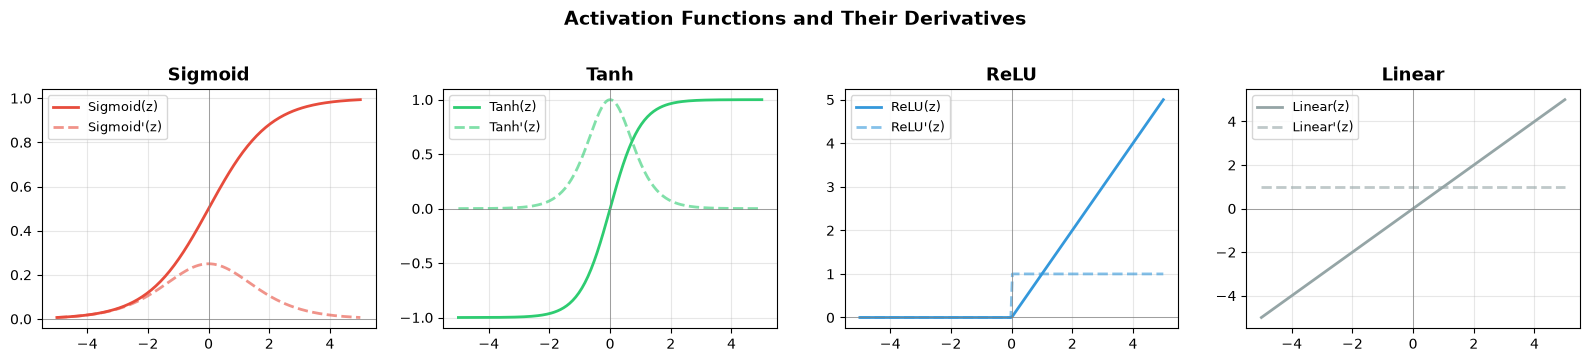

In [6]:
# --- 3.5 Activation function implementations ---

class Sigmoid:
    """Sigmoid activation function."""
    @staticmethod
    def forward(z):
        z = np.clip(z, -500, 500)  # numerical stability
        return 1.0 / (1.0 + np.exp(-z))

    @staticmethod
    def derivative(a):
        """Derivative given the activated output a = sigmoid(z)."""
        return a * (1.0 - a)

class Tanh:
    """Hyperbolic tangent activation function."""
    @staticmethod
    def forward(z):
        return np.tanh(z)

    @staticmethod
    def derivative(a):
        """Derivative given the activated output a = tanh(z)."""
        return 1.0 - a**2

class ReLU:
    """Rectified Linear Unit activation function."""
    @staticmethod
    def forward(z):
        return np.maximum(0, z)

    @staticmethod
    def derivative(a):
        """Derivative given the activated output a = relu(z)."""
        return (a > 0).astype(float)

class Linear:
    """Linear (identity) activation — used to demonstrate non-linearity necessity."""
    @staticmethod
    def forward(z):
        return z

    @staticmethod
    def derivative(a):
        return np.ones_like(a)

# Visualise activation functions
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
z = np.linspace(-5, 5, 200)

activations = [
    ('Sigmoid', Sigmoid), ('Tanh', Tanh),
    ('ReLU', ReLU), ('Linear', Linear)
]
colors = ['#e74c3c', '#2ecc71', '#3498db', '#95a5a6']

for ax, (name, act), color in zip(axes, activations, colors):
    a = act.forward(z)
    d = act.derivative(a) if name != 'ReLU' else act.derivative(act.forward(z))
    ax.plot(z, a, color=color, linewidth=2, label=f'{name}(z)')
    ax.plot(z, d, color=color, linewidth=2, linestyle='--', alpha=0.6, label=f"{name}'(z)")
    ax.axhline(y=0, color='gray', linewidth=0.5)
    ax.axvline(x=0, color='gray', linewidth=0.5)
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Activation Functions and Their Derivatives', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('activation_functions.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 4: Loss Function — Binary Cross-Entropy

For binary classification, we use **Binary Cross-Entropy (BCE)** loss:

$$\mathcal{L} = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right]$$

where $y_i \in \{0, 1\}$ is the true label and $\hat{y}_i \in (0, 1)$ is the predicted probability.

### Gradient of BCE with respect to prediction:

$$\frac{\partial \mathcal{L}}{\partial \hat{y}_i} = -\frac{y_i}{\hat{y}_i} + \frac{1 - y_i}{1 - \hat{y}_i}$$

When the output activation is **sigmoid**, the combined gradient simplifies elegantly:

$$\frac{\partial \mathcal{L}}{\partial z^{(L)}} = \hat{y} - y$$

In [7]:
def binary_cross_entropy(y_true, y_pred):
    """Compute Binary Cross-Entropy loss."""
    eps = 1e-8  # prevent log(0)
    y_pred = np.clip(y_pred, eps, 1 - eps)
    loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    return loss

def binary_cross_entropy_gradient(y_true, y_pred):
    """Gradient of BCE w.r.t. y_pred."""
    eps = 1e-8
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return (-y_true / y_pred + (1 - y_true) / (1 - y_pred)) / len(y_true)

---
## Section 5: Backpropagation Algorithm

Backpropagation computes the gradient of the loss with respect to every weight and bias in the network using the **chain rule**. These gradients tell us how to adjust each parameter to reduce the loss.

### Derivation

Consider a network with $L$ layers. For layer $l$:
- **Pre-activation:** $z^{(l)} = W^{(l)} a^{(l-1)} + b^{(l)}$
- **Activation:** $a^{(l)} = g^{(l)}(z^{(l)})$

#### Step 1: Output Layer Error
For the output layer $L$ with sigmoid activation and BCE loss:

$$\delta^{(L)} = \frac{\partial \mathcal{L}}{\partial z^{(L)}} = a^{(L)} - y$$

#### Step 2: Hidden Layer Error (propagate backwards)
For hidden layer $l$ (from $L-1$ down to $1$):

$$\delta^{(l)} = \left( W^{(l+1)T} \delta^{(l+1)} \right) \odot g'^{(l)}(a^{(l)})$$

where $\odot$ denotes element-wise multiplication.

#### Step 3: Parameter Gradients
$$\frac{\partial \mathcal{L}}{\partial W^{(l)}} = \frac{1}{N} \delta^{(l)} \cdot a^{(l-1)T}$$

$$\frac{\partial \mathcal{L}}{\partial b^{(l)}} = \frac{1}{N} \sum \delta^{(l)}$$

---
## Section 5 & 6: MLP Class with Backpropagation and Gradient Descent

We now combine everything into a complete `MLP` class.

In [8]:
class MLP:
    """
    Multi-Layer Perceptron (Feedforward Neural Network) implemented from scratch.

    Parameters
    ----------
    layer_sizes : list[int]
        Number of neurons in each layer, e.g. [13, 64, 32, 1].
    activation : str
        Activation function for hidden layers ('sigmoid', 'tanh', 'relu', 'linear').
    learning_rate : float
        Step size for gradient descent.
    """

    ACTIVATIONS = {
        'sigmoid': Sigmoid,
        'tanh': Tanh,
        'relu': ReLU,
        'linear': Linear,
    }

    def __init__(self, layer_sizes, activation='relu', learning_rate=0.01):
        self.layer_sizes = layer_sizes
        self.L = len(layer_sizes) - 1  # number of weight layers
        self.lr = learning_rate
        self.activation_name = activation
        self.hidden_act = self.ACTIVATIONS[activation]
        self.output_act = Sigmoid  # always sigmoid for binary output

        # Initialize weights and biases
        self.weights = []
        self.biases = []
        for i in range(self.L):
            n_in, n_out = layer_sizes[i], layer_sizes[i + 1]

            # He init for ReLU, Xavier for others
            if activation == 'relu':
                scale = np.sqrt(2.0 / n_in)
            else:
                scale = np.sqrt(2.0 / (n_in + n_out))

            W = np.random.randn(n_out, n_in) * scale
            b = np.zeros((n_out, 1))
            self.weights.append(W)
            self.biases.append(b)

    def forward(self, X):
        """
        Forward pass through the network.

        Parameters
        ----------
        X : ndarray, shape (n_features, n_samples)

        Returns
        -------
        output : ndarray, shape (1, n_samples)
        """
        self.a = [X]  # cache activations for backprop
        self.z = []    # cache pre-activations

        for l in range(self.L):
            z_l = self.weights[l] @ self.a[l] + self.biases[l]
            self.z.append(z_l)

            if l == self.L - 1:
                # Output layer: always sigmoid
                a_l = self.output_act.forward(z_l)
            else:
                # Hidden layers: chosen activation
                a_l = self.hidden_act.forward(z_l)

            self.a.append(a_l)

        return self.a[-1]

    def backward(self, y):
        """
        Backpropagation: compute gradients for all weights and biases.

        Parameters
        ----------
        y : ndarray, shape (1, n_samples) — true labels.
        """
        m = y.shape[1]  # number of samples
        self.dW = [None] * self.L
        self.db = [None] * self.L

        # --- Output layer delta ---
        # For sigmoid + BCE: delta = a - y (simplified gradient)
        delta = self.a[-1] - y  # shape (1, m)

        # Gradient for last layer
        self.dW[-1] = (1.0 / m) * (delta @ self.a[-2].T)
        self.db[-1] = (1.0 / m) * np.sum(delta, axis=1, keepdims=True)

        # --- Hidden layers (propagate backwards) ---
        for l in range(self.L - 2, -1, -1):
            # Propagate delta through weights
            delta = (self.weights[l + 1].T @ delta) * self.hidden_act.derivative(self.a[l + 1])

            self.dW[l] = (1.0 / m) * (delta @ self.a[l].T)
            self.db[l] = (1.0 / m) * np.sum(delta, axis=1, keepdims=True)

    def update_parameters(self):
        """Apply gradient descent update to all parameters."""
        for l in range(self.L):
            self.weights[l] -= self.lr * self.dW[l]
            self.biases[l] -= self.lr * self.db[l]

    def train(self, X_train, y_train, X_val=None, y_val=None, epochs=200, batch_size=32, verbose=True):
        """
        Train the MLP using mini-batch gradient descent.

        Returns
        -------
        history : dict with 'train_loss', 'val_loss', 'train_acc', 'val_acc' per epoch.
        """
        # Transpose data to shape (features, samples) for matrix math
        X_t = X_train.T
        y_t = y_train.reshape(1, -1)

        if X_val is not None:
            X_v = X_val.T
            y_v = y_val.reshape(1, -1)

        m = X_t.shape[1]
        history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

        for epoch in range(epochs):
            # Shuffle training data
            perm = np.random.permutation(m)
            X_shuffled = X_t[:, perm]
            y_shuffled = y_t[:, perm]

            # Mini-batch gradient descent
            for start in range(0, m, batch_size):
                end = min(start + batch_size, m)
                X_batch = X_shuffled[:, start:end]
                y_batch = y_shuffled[:, start:end]

                # Forward pass
                self.forward(X_batch)
                # Backward pass
                self.backward(y_batch)
                # Update weights
                self.update_parameters()

            # Compute epoch metrics on full data
            y_pred_train = self.forward(X_t)
            train_loss = binary_cross_entropy(y_t.flatten(), y_pred_train.flatten())
            train_acc = np.mean((y_pred_train.flatten() > 0.5) == y_t.flatten())
            history['train_loss'].append(train_loss)
            history['train_acc'].append(train_acc)

            if X_val is not None:
                y_pred_val = self.forward(X_v)
                val_loss = binary_cross_entropy(y_v.flatten(), y_pred_val.flatten())
                val_acc = np.mean((y_pred_val.flatten() > 0.5) == y_v.flatten())
                history['val_loss'].append(val_loss)
                history['val_acc'].append(val_acc)

            if verbose and (epoch + 1) % 50 == 0:
                msg = f"Epoch {epoch+1:4d}/{epochs} — Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}"
                if X_val is not None:
                    msg += f" | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
                print(msg)

        return history

    def predict(self, X):
        """Return predicted probabilities."""
        return self.forward(X.T).flatten()

    def predict_classes(self, X):
        """Return binary predictions (threshold=0.5)."""
        return (self.predict(X) > 0.5).astype(int)

---
## Section 6: Training with Gradient Descent

**Gradient Descent** iteratively updates the network parameters to minimise the loss:

$$W^{(l)} \leftarrow W^{(l)} - \eta \frac{\partial \mathcal{L}}{\partial W^{(l)}}$$

$$b^{(l)} \leftarrow b^{(l)} - \eta \frac{\partial \mathcal{L}}{\partial b^{(l)}}$$

where $\eta$ is the **learning rate**.

We use **mini-batch gradient descent** which processes small batches of samples at each step, balancing the stability of batch GD with the speed of stochastic GD.

In [9]:
# --- 6.1 Train with the ReLU activation (baseline) ---

n_features = X_train_final.shape[1]
print(f"Number of input features: {n_features}")

model_relu = MLP(
    layer_sizes=[n_features, 64, 32, 1],
    activation='relu',
    learning_rate=0.01
)

print("\n=== Training MLP with ReLU activation ===")
history_relu = model_relu.train(
    X_train_final, y_train_final,
    X_val_final, y_val_final,
    epochs=300, batch_size=32
)

Number of input features: 14

=== Training MLP with ReLU activation ===


Epoch   50/300 — Train Loss: 0.5561, Train Acc: 0.7017 | Val Loss: 0.5995, Val Acc: 0.6667


Epoch  100/300 — Train Loss: 0.5255, Train Acc: 0.7202 | Val Loss: 0.6113, Val Acc: 0.6441


Epoch  150/300 — Train Loss: 0.5078, Train Acc: 0.7628 | Val Loss: 0.5808, Val Acc: 0.6893


Epoch  200/300 — Train Loss: 0.5235, Train Acc: 0.7259 | Val Loss: 0.5904, Val Acc: 0.7232


Epoch  250/300 — Train Loss: 0.4716, Train Acc: 0.7656 | Val Loss: 0.6061, Val Acc: 0.6384


Epoch  300/300 — Train Loss: 0.4563, Train Acc: 0.7827 | Val Loss: 0.5974, Val Acc: 0.6723


---
## Section 7: Experiments & Comparative Analysis

We now train the MLP with different activation functions under identical settings and compare:
1. **Training & validation loss curves**
2. **Final accuracy**
3. **Linear vs. non-linear** (demonstrating necessity of non-linearity)

In [10]:
# --- 7.1 Train with all activation functions ---

EPOCHS = 300
LR = 0.01
ARCH = [n_features, 64, 32, 1]
BATCH_SIZE = 32

results = {}

for act_name in ['sigmoid', 'tanh', 'relu']:
    print(f"\n{'='*50}")
    print(f"  Training MLP with {act_name.upper()} activation")
    print(f"{'='*50}")

    np.random.seed(42)  # same init for fair comparison
    model = MLP(layer_sizes=ARCH, activation=act_name, learning_rate=LR)
    history = model.train(
        X_train_final, y_train_final,
        X_val_final, y_val_final,
        epochs=EPOCHS, batch_size=BATCH_SIZE
    )
    results[act_name] = {
        'model': model,
        'history': history,
        'final_train_loss': history['train_loss'][-1],
        'final_val_loss': history['val_loss'][-1],
        'final_train_acc': history['train_acc'][-1],
        'final_val_acc': history['val_acc'][-1],
    }

# Also train with LINEAR activation to demonstrate non-linearity necessity
print(f"\n{'='*50}")
print(f"  Training MLP with LINEAR activation (no non-linearity)")
print(f"{'='*50}")

np.random.seed(42)
model_linear = MLP(layer_sizes=ARCH, activation='linear', learning_rate=0.001)  # lower LR for stability
history_linear = model_linear.train(
    X_train_final, y_train_final,
    X_val_final, y_val_final,
    epochs=EPOCHS, batch_size=BATCH_SIZE
)
results['linear'] = {
    'model': model_linear,
    'history': history_linear,
    'final_train_loss': history_linear['train_loss'][-1],
    'final_val_loss': history_linear['val_loss'][-1],
    'final_train_acc': history_linear['train_acc'][-1],
    'final_val_acc': history_linear['val_acc'][-1],
}


  Training MLP with SIGMOID activation


Epoch   50/300 — Train Loss: 0.6794, Train Acc: 0.5810 | Val Loss: 0.6865, Val Acc: 0.5819


Epoch  100/300 — Train Loss: 0.6652, Train Acc: 0.6151 | Val Loss: 0.6731, Val Acc: 0.6215


Epoch  150/300 — Train Loss: 0.6446, Train Acc: 0.6747 | Val Loss: 0.6553, Val Acc: 0.6102


Epoch  200/300 — Train Loss: 0.6161, Train Acc: 0.7031 | Val Loss: 0.6325, Val Acc: 0.6441


...

Epoch  100/300 — Train Loss: 0.5841, Train Acc: 0.6960 | Val Loss: 0.6235, Val Acc: 0.6215


Epoch  150/300 — Train Loss: 0.5736, Train Acc: 0.7145 | Val Loss: 0.6206, Val Acc: 0.6328


Epoch  200/300 — Train Loss: 0.6019, Train Acc: 0.6676 | Val Loss: 0.6340, Val Acc: 0.6328


Epoch  250/300 — Train Loss: 0.5886, Train Acc: 0.6903 | Val Loss: 0.6317, Val Acc: 0.6554


Epoch  300/300 — Train Loss: 0.7466, Train Acc: 0.6293 | Val Loss: 0.7445, Val Acc: 0.6215


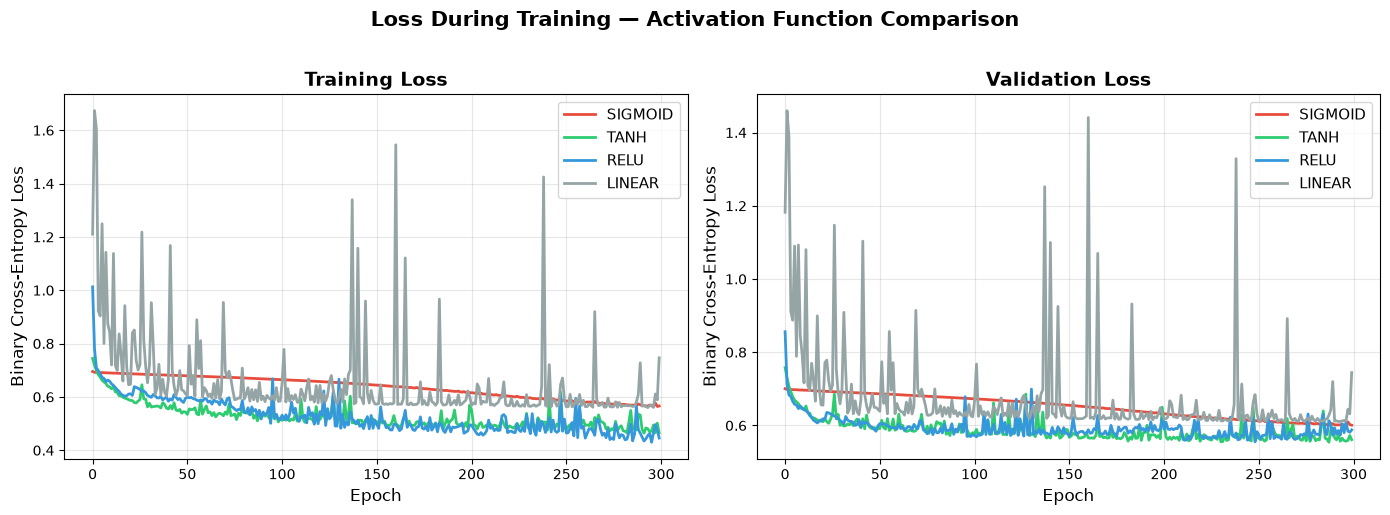

In [11]:
# --- 7.2 Loss curve comparison ---

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_map = {
    'sigmoid': '#e74c3c',
    'tanh': '#2ecc71',
    'relu': '#3498db',
    'linear': '#95a5a6'
}

# Training Loss
ax = axes[0]
for name, res in results.items():
    ax.plot(res['history']['train_loss'], label=name.upper(),
            color=colors_map[name], linewidth=2)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Binary Cross-Entropy Loss', fontsize=12)
ax.set_title('Training Loss', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Validation Loss
ax = axes[1]
for name, res in results.items():
    ax.plot(res['history']['val_loss'], label=name.upper(),
            color=colors_map[name], linewidth=2)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Binary Cross-Entropy Loss', fontsize=12)
ax.set_title('Validation Loss', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.suptitle('Loss During Training — Activation Function Comparison', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('loss_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

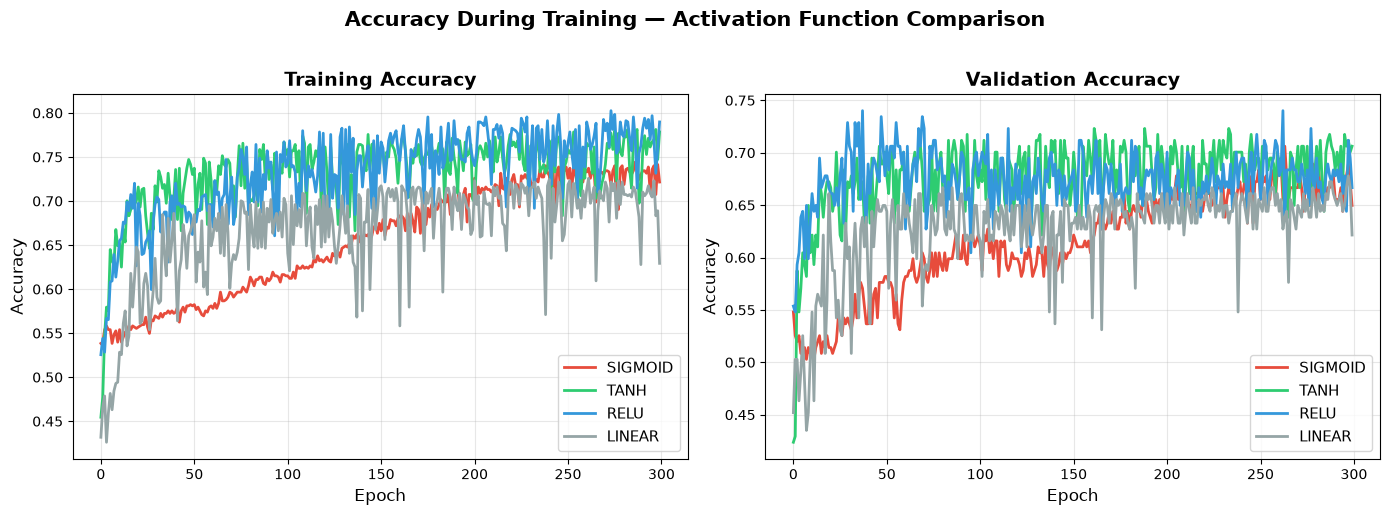

In [12]:
# --- 7.3 Accuracy curves ---

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training Accuracy
ax = axes[0]
for name, res in results.items():
    ax.plot(res['history']['train_acc'], label=name.upper(),
            color=colors_map[name], linewidth=2)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Training Accuracy', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Validation Accuracy
ax = axes[1]
for name, res in results.items():
    ax.plot(res['history']['val_acc'], label=name.upper(),
            color=colors_map[name], linewidth=2)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Validation Accuracy', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.suptitle('Accuracy During Training — Activation Function Comparison', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# --- 7.4 Summary table ---

print("\n" + "="*80)
print("  PERFORMANCE COMPARISON — ACTIVATION FUNCTIONS")
print("="*80)
print(f"{'Activation':<12} {'Train Loss':>12} {'Val Loss':>12} {'Train Acc':>12} {'Val Acc':>12}")
print("-" * 60)
for name in ['sigmoid', 'tanh', 'relu', 'linear']:
    r = results[name]
    print(f"{name.upper():<12} {r['final_train_loss']:>12.4f} {r['final_val_loss']:>12.4f} "
          f"{r['final_train_acc']:>12.4f} {r['final_val_acc']:>12.4f}")
print("-" * 60)


  PERFORMANCE COMPARISON — ACTIVATION FUNCTIONS
Activation     Train Loss     Val Loss    Train Acc      Val Acc
------------------------------------------------------------
SIGMOID            0.5661       0.6008       0.7216       0.6497
TANH               0.4656       0.5612       0.7784       0.7062
RELU               0.4460       0.5878       0.7898       0.6667
LINEAR             0.7466       0.7445       0.6293       0.6215
------------------------------------------------------------


### 7.5 Demonstrating the Necessity of Non-Linearity

The table above shows that the **LINEAR activation** (no non-linearity) performs significantly worse than the non-linear activations. This is because:

1. **A deep linear network is equivalent to a single linear layer:** $f(x) = W_3 W_2 W_1 x + b = W' x + b'$
2. The decision boundary of a linear model is a **hyperplane** — it cannot capture the complex, non-linear patterns in mouse dynamics data.
3. Non-linear activations (Sigmoid, Tanh, ReLU) allow the network to learn **hierarchical, non-linear features** that distinguish legal from illegal sessions.

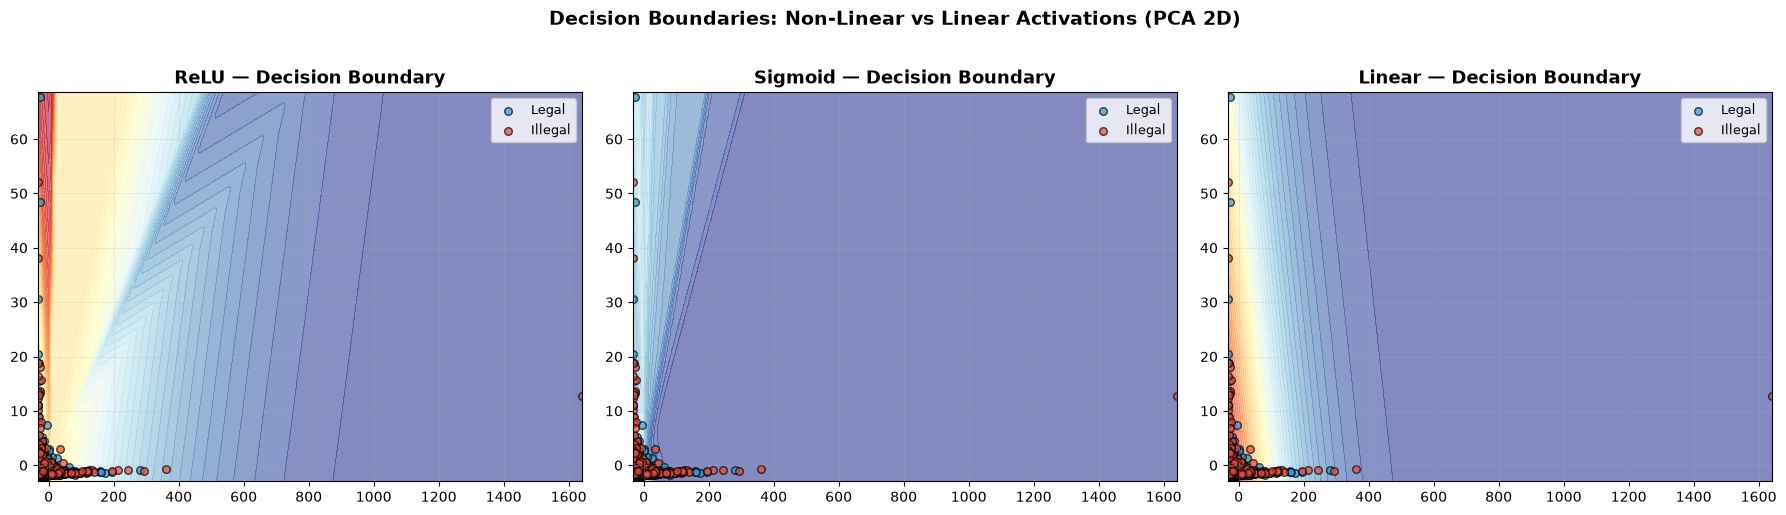

In [14]:
# --- 7.6 Visualize decision regions on 2 PCA components (for intuition) ---

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train_final)
X_val_2d = pca.transform(X_val_final)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, act_name) in zip(axes, [('ReLU', 'relu'), ('Sigmoid', 'sigmoid'), ('Linear', 'linear')]):
    # Train a small MLP on 2D data
    np.random.seed(42)
    small_model = MLP([2, 16, 8, 1], activation=act_name, learning_rate=0.01 if act_name != 'linear' else 0.001)
    small_model.train(X_train_2d, y_train_final, epochs=300, batch_size=32, verbose=False)

    # Create meshgrid for decision boundary
    x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
    y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                          np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = small_model.predict(grid).reshape(xx.shape)

    ax.contourf(xx, yy, Z, levels=50, cmap='RdYlBu', alpha=0.6)
    ax.scatter(X_train_2d[y_train_final==0, 0], X_train_2d[y_train_final==0, 1],
               c='#3498db', edgecolors='k', s=30, alpha=0.7, label='Legal')
    ax.scatter(X_train_2d[y_train_final==1, 0], X_train_2d[y_train_final==1, 1],
               c='#e74c3c', edgecolors='k', s=30, alpha=0.7, label='Illegal')
    ax.set_title(f'{name} — Decision Boundary', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2)

plt.suptitle('Decision Boundaries: Non-Linear vs Linear Activations (PCA 2D)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('decision_boundaries.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Conclusion

1. **MLP Architecture:** We implemented a configurable feedforward neural network from scratch using NumPy with support for arbitrary layer configurations.

2. **Activation Functions:** Sigmoid, Tanh, and ReLU were implemented with their derivatives. ReLU generally converges faster due to mitigating the vanishing gradient problem, while Sigmoid and Tanh can suffer from saturation.

3. **Non-Linearity is Essential:** The linear activation experiment clearly demonstrated that without non-linear activation functions, even deep networks cannot learn complex patterns — they collapse to a single linear transformation.

4. **Binary Cross-Entropy Loss** was used as the cost function, appropriate for binary classification tasks.

5. **Backpropagation** was derived step-by-step and implemented to compute gradients efficiently via the chain rule, propagating error signals from the output back through hidden layers.

6. **Gradient Descent** (mini-batch) was applied to iteratively minimise the loss function by updating weights in the direction of steepest descent.

7. **Comparative Analysis** showed the training dynamics and final performance across different activation functions, with non-linear activations significantly outperforming the linear baseline.